# Semana 3: Dinámica sobre Redes
## Systems Analytics — MISE

**Objetivo:** Entender cómo se propagan fenómenos (información, adopción tecnológica, fallas) a través de redes, y aplicar estos modelos al sector energético colombiano.

| Nivel | Tema | Enfoque |
|-------|------|--------|
| **Nivel 1 —** Intuición | Contagio, umbrales, curva S | Algoritmos visibles, analogías |
| **Nivel 2 —** Energía | Adopción solar, mercado mayorista | Datos colombianos |
| **Nivel 3 —** Profesional | ABM, resiliencia, política | Herramientas avanzadas |

---

In [1]:
import sys; sys.path.insert(0, '.')
from mise_utils import viz, energy_data
from mise_utils import diffusion
from mise_utils.viz import COLORS
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
viz.apply_mise_style()

print("Semana 3 cargada correctamente")
print(f"   NetworkX {nx.__version__}")

Semana 3 cargada correctamente
   NetworkX 3.1


---
# Nivel 1 **Nivel 1 —** Intuición: ¿Cómo se propagan las cosas en redes?

> En la Semana 2 aprendimos a **describir** redes. Ahora la pregunta es: ¿qué **sucede** sobre ellas?
> Un rumor, un virus, una tecnología... todos se propagan por las conexiones.

## 1.1 El rumor en el salón de clase 

¿Cómo se esparce un rumor? Empecemos con el modelo más simple: **contagio simple (SI)**.

**Regla:** En cada paso de tiempo, cada persona infectada le "cuenta" el rumor a cada vecino con probabilidad β.

Este es el algoritmo completo — léelo línea por línea:

In [2]:
# ═══════════════════════════════════════════════════════════════════
# ALGORITMO DE CONTAGIO SIMPLE (SI) — CÓDIGO VISIBLE
# ═══════════════════════════════════════════════════════════════════

def contagio_simple_manual(G, semilla, beta=0.15, n_pasos=20):
    """Modelo SI paso a paso — el estudiante puede leer cada línea."""
    rng = np.random.default_rng(42)
    
    # Paso 0: solo la semilla está infectada
    infectados = {semilla}
    historia = [infectados.copy()]
    
    for paso in range(n_pasos):
        nuevos = set()  # nuevos infectados en ESTE paso
        
        # Cada infectado intenta contagiar a sus vecinos
        for nodo in infectados:
            for vecino in G.neighbors(nodo):
                if vecino not in infectados:       # solo susceptibles
                    if rng.random() < beta:        # con probabilidad β
                        nuevos.add(vecino)
        
        # Actualizar: los nuevos se suman a los infectados
        infectados = infectados | nuevos
        historia.append(infectados.copy())
    
    return historia

print("Función definida. Ahora vamos a usarla.")

Función definida. Ahora vamos a usarla.


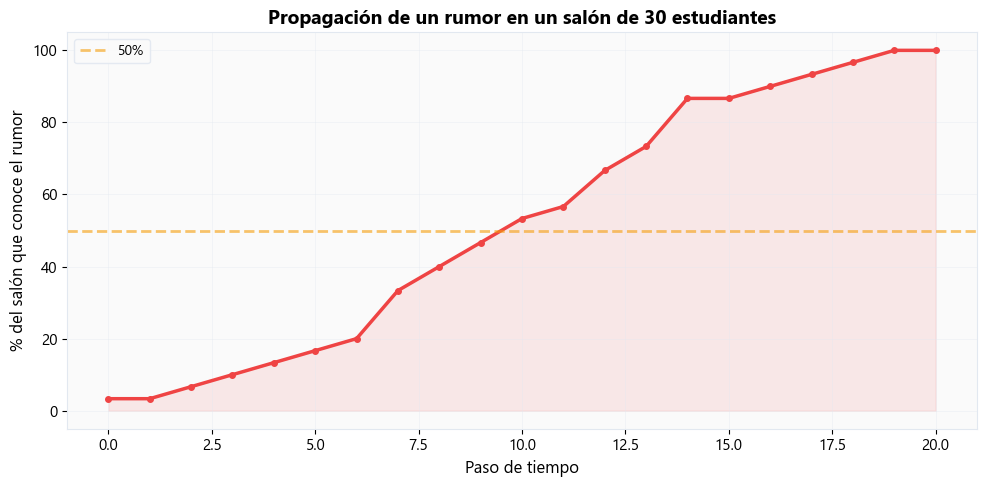


El rumor llegó al 100% del salón en 20 pasos


In [3]:
# Crear una red tipo "salón de clase" (small-world)
G_salon = nx.watts_strogatz_graph(30, k=4, p=0.3, seed=42)

# Correr el contagio desde el nodo 0
historia = contagio_simple_manual(G_salon, semilla=0, beta=0.15)

# Graficar la curva de contagio
t, fraccion = diffusion.curva_contagio(historia, len(G_salon))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, fraccion * 100, color=COLORS["danger"], linewidth=2.5, marker='o', markersize=4)
ax.fill_between(t, 0, fraccion * 100, color=COLORS["danger"], alpha=0.1)
ax.set_xlabel("Paso de tiempo")
ax.set_ylabel("% del salón que conoce el rumor")
ax.set_title("Propagación de un rumor en un salón de 30 estudiantes", fontweight="bold")
ax.axhline(y=50, color=COLORS["accent"], linestyle='--', alpha=0.6, label="50%")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nEl rumor llegó al {fraccion[-1]*100:.0f}% del salón en {len(historia)-1} pasos")

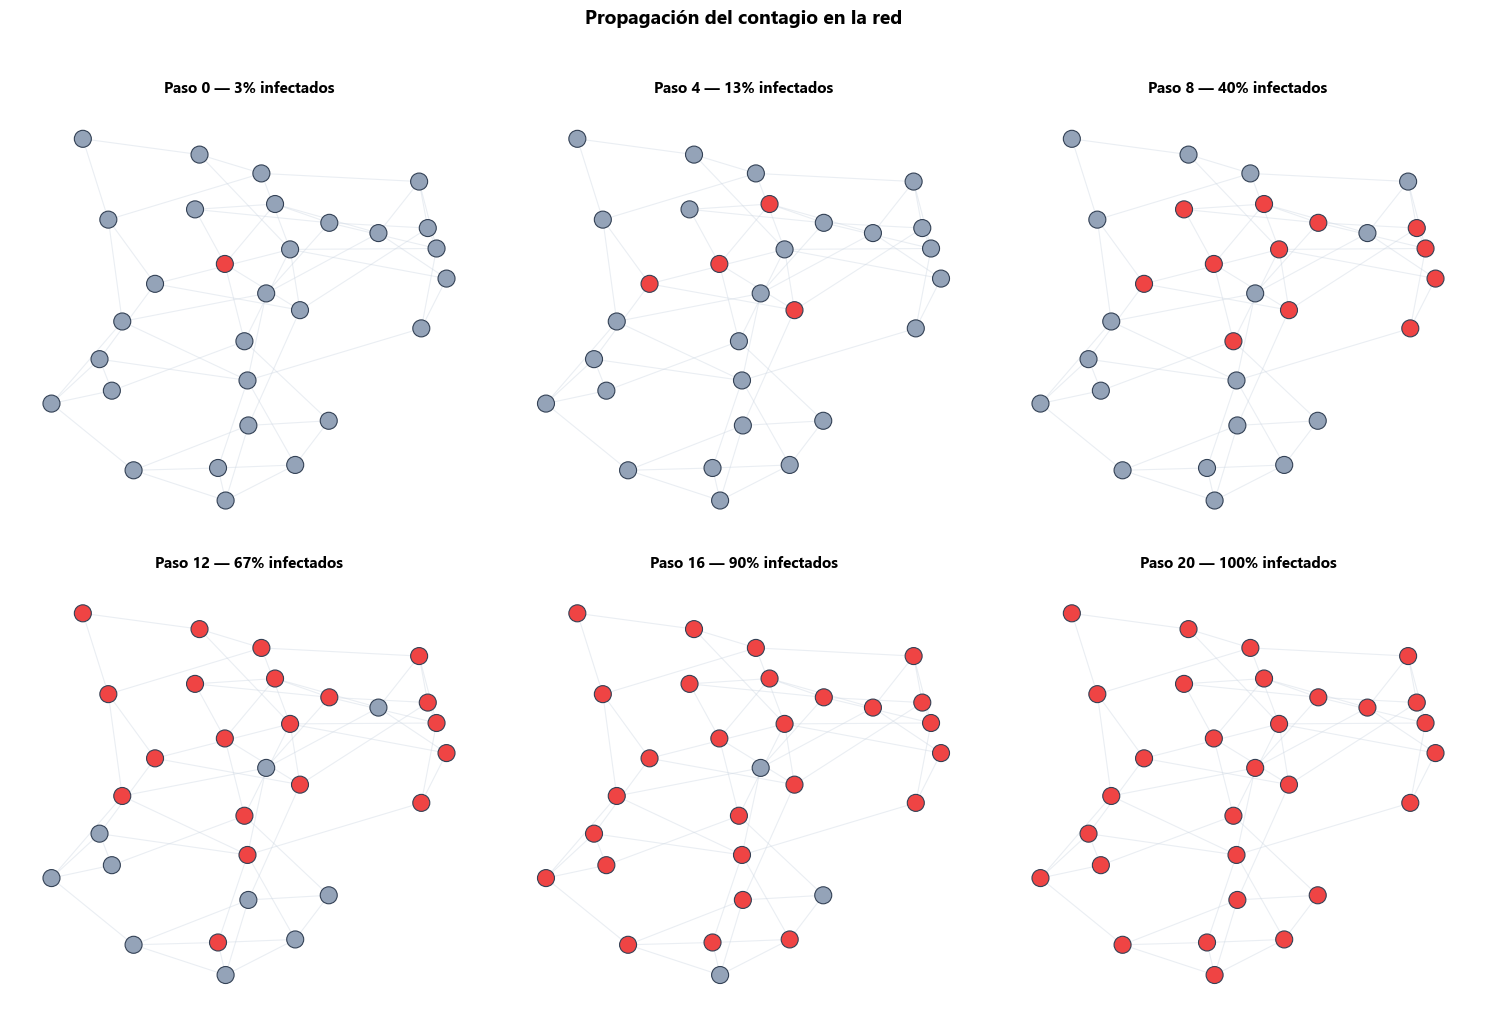

In [4]:
# Visualizar la propagación en la red
fig = diffusion.plot_propagacion(G_salon, historia)
plt.show()

## 1.2 ¿Por qué todos usan WhatsApp? — Contagio simple vs complejo 

**Contagio simple** (rumor, virus): basta que UN vecino te lo pase → adoptas.

**Contagio complejo** (WhatsApp, paneles solares): necesitas que VARIOS vecinos ya lo usen → adoptas.

> La diferencia es el **umbral**: ¿cuántos de mis contactos necesitan tenerlo para que yo lo adopte?

Comparemos ambos en la misma red:

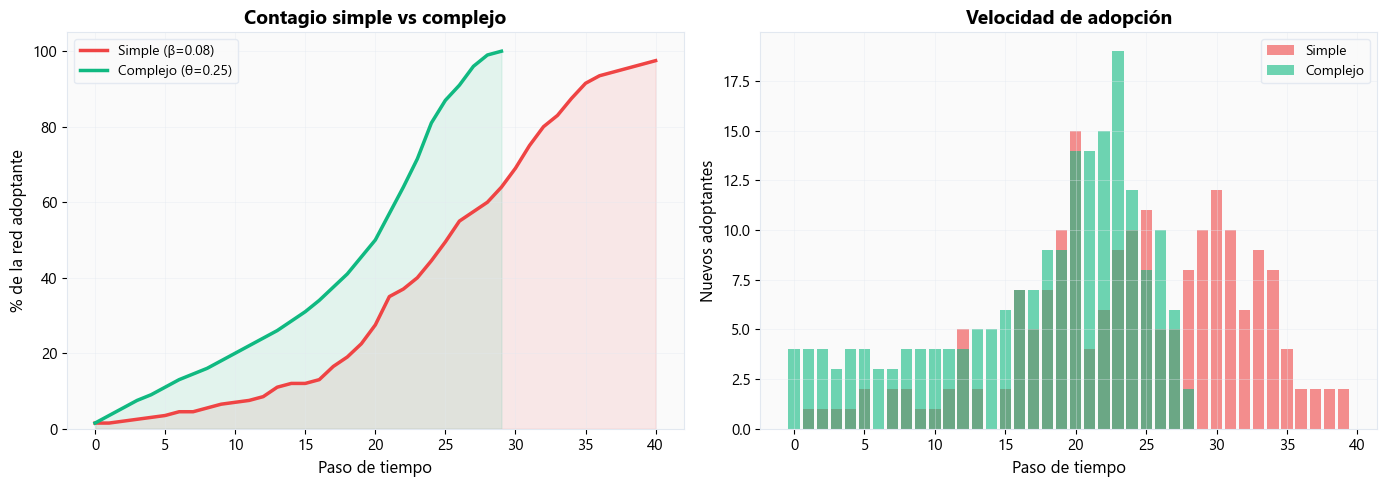

**Nota:** Observa: el contagio simple es gradual y continuo.
   El contagio complejo puede 'estancarse' o 'explotar' dependiendo del umbral.


In [5]:
# Red más grande para ver la diferencia
G_social = nx.watts_strogatz_graph(200, k=6, p=0.1, seed=42)
semillas = {0, 1, 2}  # 3 personas empiezan

fig = diffusion.comparar_simple_vs_complejo(
    G_social, semillas,
    beta=0.08,      # probabilidad de contagio simple
    umbral=0.25,    # umbral de contagio complejo (25% de vecinos)
    n_pasos=40
)
plt.show()

print("**Nota:** Observa: el contagio simple es gradual y continuo.")
print("   El contagio complejo puede 'estancarse' o 'explotar' dependiendo del umbral.")

## 1.3 El modelo de umbrales — ¿cuándo ocurre una cascada? ️

Cada persona tiene un **umbral personal**: la fracción de vecinos que necesitan haber adoptado para que ella también adopte.

Este es el algoritmo completo del modelo de cascada por umbrales:

In [6]:
# ═══════════════════════════════════════════════════════════════════
# MODELO DE CASCADA POR UMBRALES — CÓDIGO VISIBLE
# ═══════════════════════════════════════════════════════════════════

def cascada_umbrales_manual(G, semillas, umbrales):
    """Modelo de umbral paso a paso — el estudiante puede leer cada línea."""
    adoptantes = set(semillas)
    historia = [adoptantes.copy()]
    
    for paso in range(50):  # máximo 50 pasos
        nuevos = set()
        
        for nodo in G.nodes():
            if nodo not in adoptantes:
                # Contar vecinos que ya adoptaron
                vecinos_adoptantes = sum(
                    1 for v in G.neighbors(nodo) if v in adoptantes
                )
                # Calcular la fracción
                fraccion = vecinos_adoptantes / max(G.degree(nodo), 1)
                
                # ¿Supera mi umbral personal?
                if fraccion >= umbrales[nodo]:
                    nuevos.add(nodo)
        
        if not nuevos:  # nadie nuevo adoptó → la cascada se detuvo
            break
        
        adoptantes = adoptantes | nuevos
        historia.append(adoptantes.copy())
    
    return historia

print("Función definida.")

Función definida.


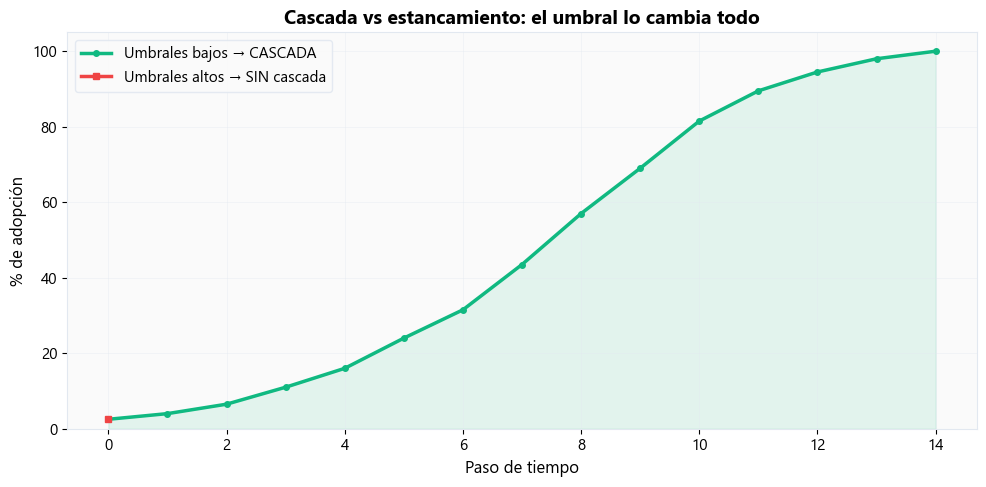

In [7]:
# Comparar: umbrales bajos (cascada) vs altos (sin cascada)
G_cascada = nx.watts_strogatz_graph(200, k=6, p=0.1, seed=42)
semillas = {0, 1, 2, 3, 4}

# Caso 1: umbrales bajos → CASCADA
umbrales_bajos = diffusion.generar_umbrales(G_cascada, 'uniforme', seed=42)

# Caso 2: umbrales altos → SIN CASCADA
umbrales_altos = {n: 0.45 for n in G_cascada.nodes()}

hist_cascada = cascada_umbrales_manual(G_cascada, semillas, umbrales_bajos)
hist_no_cascada = cascada_umbrales_manual(G_cascada, semillas, umbrales_altos)

N = len(G_cascada)
t1, f1 = diffusion.curva_contagio(hist_cascada, N)
t2, f2 = diffusion.curva_contagio(hist_no_cascada, N)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t1, f1 * 100, color=COLORS["success"], linewidth=2.5, marker='o',
        markersize=4, label="Umbrales bajos → CASCADA")
ax.plot(t2, f2 * 100, color=COLORS["danger"], linewidth=2.5, marker='s',
        markersize=4, label="Umbrales altos → SIN cascada")
ax.fill_between(t1, 0, f1 * 100, color=COLORS["success"], alpha=0.1)
ax.set_xlabel("Paso de tiempo")
ax.set_ylabel("% de adopción")
ax.set_title("Cascada vs estancamiento: el umbral lo cambia todo", fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## 1.4 La curva S de Instagram 

¿Por qué la adopción de tecnologías tiene forma de **S**?

El **modelo de Bass** (1969) lo explica con dos fuerzas:
- **p** (innovación): personas que adoptan por iniciativa propia (publicidad, curiosidad)
- **q** (imitación): personas que adoptan porque ven que otros lo usan

La ecuación diferencial es:

$$\frac{dF}{dt} = (p + qF)(1 - F)$$

donde $F(t)$ es la fracción acumulada de adoptantes.

> **Nota:** **Nota:** Formalizaremos las ecuaciones diferenciales ordinarias (ODEs) en la **Semana 4** sobre Dinámica de Sistemas. Por ahora, enfoquémonos en la *intuición* de la curva S.

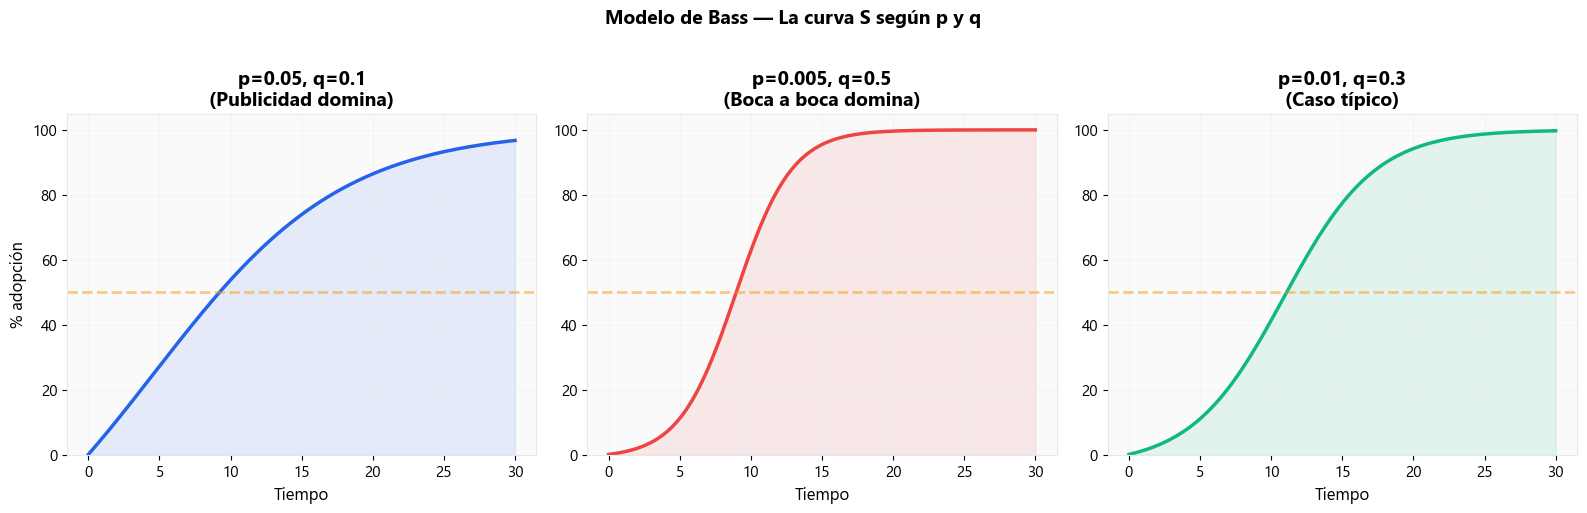

**Nota:** Cuando q >> p, la curva S es más pronunciada (efecto 'boca a boca').
   Cuando p es alto, la adopción arranca rápido pero sin 'explosión' social.


In [8]:
# Explorar el modelo de Bass con diferentes parámetros
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Caso 1: Dominado por innovación (p alto)
t1, F1, dF1 = diffusion.resolver_bass(p=0.05, q=0.1, T=30)
axes[0].plot(t1, F1 * 100, color=COLORS["primary"], linewidth=2.5)
axes[0].fill_between(t1, 0, F1 * 100, color=COLORS["primary"], alpha=0.1)
axes[0].set_title("p=0.05, q=0.1\n(Publicidad domina)", fontweight="bold")
axes[0].set_ylabel("% adopción")
axes[0].set_ylim(0, 105)

# Caso 2: Dominado por imitación (q alto)
t2, F2, dF2 = diffusion.resolver_bass(p=0.005, q=0.5, T=30)
axes[1].plot(t2, F2 * 100, color=COLORS["danger"], linewidth=2.5)
axes[1].fill_between(t2, 0, F2 * 100, color=COLORS["danger"], alpha=0.1)
axes[1].set_title("p=0.005, q=0.5\n(Boca a boca domina)", fontweight="bold")
axes[1].set_ylim(0, 105)

# Caso 3: Mixto (caso típico)
t3, F3, dF3 = diffusion.resolver_bass(p=0.01, q=0.3, T=30)
axes[2].plot(t3, F3 * 100, color=COLORS["success"], linewidth=2.5)
axes[2].fill_between(t3, 0, F3 * 100, color=COLORS["success"], alpha=0.1)
axes[2].set_title("p=0.01, q=0.3\n(Caso típico)", fontweight="bold")
axes[2].set_ylim(0, 105)

for ax in axes:
    ax.set_xlabel("Tiempo")
    ax.axhline(y=50, color=COLORS["accent"], linestyle='--', alpha=0.5)

fig.suptitle("Modelo de Bass — La curva S según p y q",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("**Nota:** Cuando q >> p, la curva S es más pronunciada (efecto 'boca a boca').")
print("   Cuando p es alto, la adopción arranca rápido pero sin 'explosión' social.")

---
# Nivel 2 **Nivel 2 —** Energía: Difusión y redes en el sector eléctrico colombiano

> Ahora aplicamos los modelos de contagio y difusión al contexto energético real.

## 2.1 Adopción solar en un barrio — ¿Cuándo se alcanza el tipping point? ️

La adopción de paneles solares es un caso clásico de **contagio complejo**:
- No basta con que UN vecino tenga paneles
- Necesitas ver que VARIOS vecinos lo hicieron (prueba social, información, confianza)

¿Qué pasa si el gobierno **subsidia** la instalación? El subsidio **reduce el umbral** de cada persona.

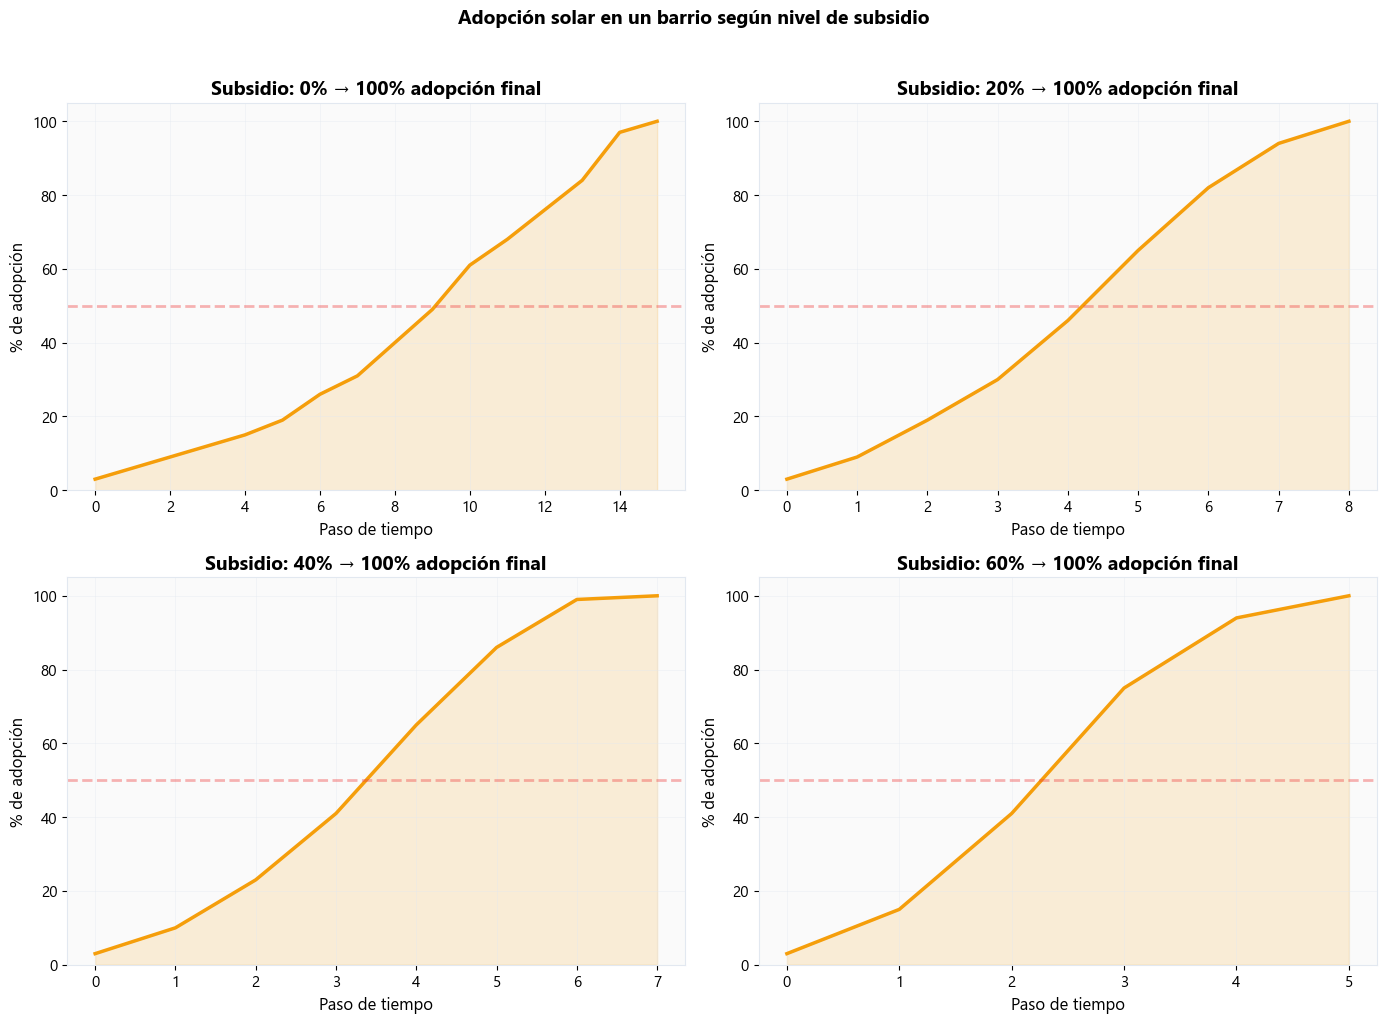

**Nota:** Existe un 'punto de inflexión': un nivel de subsidio donde la adopción
   pasa de estancarse a propagarse por toda la red.
   → Esto ayuda a diseñar políticas eficientes de transición energética.


In [9]:
# Crear la red de un barrio
G_barrio = energy_data.crear_red_barrio(n_casas=100, tipo='small_world', seed=42)

# Semillas: 3 innovadores
semillas = {0, 10, 50}

# Simular con diferentes niveles de subsidio (que bajan el umbral)
subsidios = [0, 20, 40, 60]  # % de subsidio

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, subsidio in enumerate(subsidios):
    # Umbral base depende del ingreso; subsidio lo reduce
    umbrales = {}
    for n in G_barrio.nodes():
        ingreso = G_barrio.nodes[n].get("ingreso", "medio")
        base = {"alto": 0.15, "medio": 0.30, "bajo": 0.45}[ingreso]
        umbrales[n] = max(0.05, base - subsidio / 100 * 0.3)
    
    hist = diffusion.simular_contagio_complejo(G_barrio, semillas, umbrales)
    t, f = diffusion.curva_contagio(hist, len(G_barrio))
    
    ax = axes[idx]
    ax.plot(t, f * 100, color=COLORS["accent"], linewidth=2.5)
    ax.fill_between(t, 0, f * 100, color=COLORS["accent"], alpha=0.15)
    ax.set_xlabel("Paso de tiempo")
    ax.set_ylabel("% de adopción")
    ax.set_title(f"Subsidio: {subsidio}% \u2192 {f[-1]*100:.0f}% adopción final",
                 fontweight="bold")
    ax.set_ylim(0, 105)
    ax.axhline(y=50, color=COLORS["danger"], linestyle='--', alpha=0.4)

fig.suptitle("Adopción solar en un barrio según nivel de subsidio",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("**Nota:** Existe un 'punto de inflexión': un nivel de subsidio donde la adopción")
print("   pasa de estancarse a propagarse por toda la red.")
print("   \u2192 Esto ayuda a diseñar políticas eficientes de transición energética.")

## 2.2 Curva S de las FNCER en Colombia 🇨🇴

Las **Fuentes No Convencionales de Energía Renovable** (FNCER) — solar, eólica — están en plena fase de adopción en Colombia.

Vamos a ajustar el **modelo de Bass** a datos de capacidad solar instalada.

In [10]:
# Datos de adopción solar en Colombia (sintéticos pero realistas)
df_solar = energy_data.generar_adopcion_solar_colombia()
print("Datos de adopción solar:")
print(df_solar.to_string(index=False))

Datos de adopción solar:
 año  capacidad_mw  instalaciones  tasa_crecimiento_pct
2015           3.0            647                   0.0
2016           8.5           1711                 183.3
2017          55.7          12396                 555.3
2018         102.5          21458                  84.0
2019         141.8          25923                  38.3
2020         249.5          51740                  76.0
2021         409.5          74047                  64.1
2022         605.6         131760                  47.9
2023         868.5         172833                  43.4
2024        1171.9         230047                  34.9
2025        1530.2         285201                  30.6



 Parámetros ajustados del modelo de Bass:
   p (innovación) = 0.00410
   q (imitación)  = 0.598
   Ratio q/p      = 146


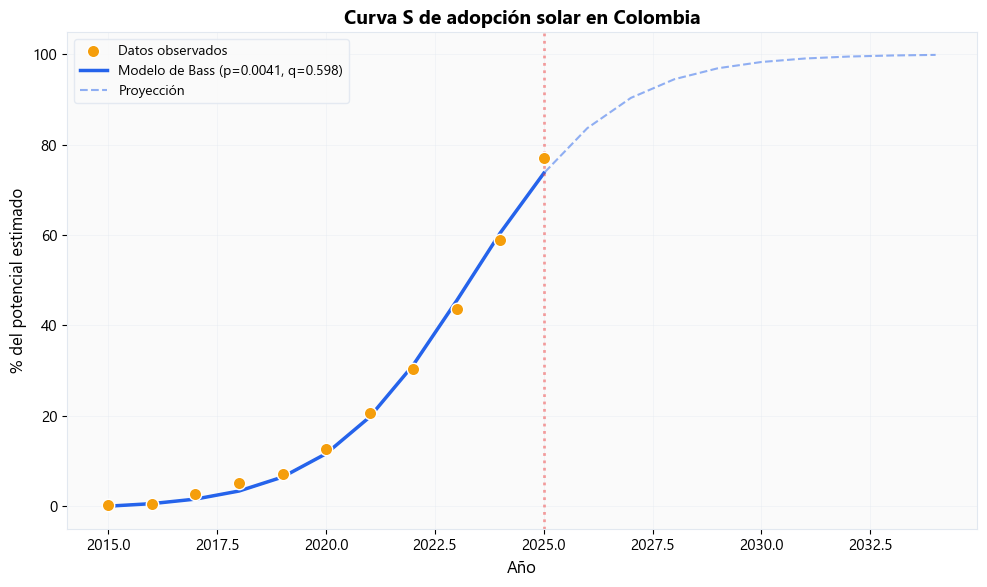


**Nota:** Interpretación:
   • q/p = 146 → la imitación social domina la adopción
   • La curva S sugiere que Colombia está entrando en la fase de aceleración


In [11]:
# Normalizar datos para ajustar Bass
anios = df_solar["a\u00f1o"].values
capacidad = df_solar["capacidad_mw"].values
cap_max = capacidad.max() * 1.3  # estimación del potencial total
datos_norm = capacidad / cap_max

# Ajustar p y q
p_opt, q_opt, F_ajustada = diffusion.ajustar_bass(anios, datos_norm)

print(f"\n Parámetros ajustados del modelo de Bass:")
print(f"   p (innovación) = {p_opt:.5f}")
print(f"   q (imitación)  = {q_opt:.3f}")
print(f"   Ratio q/p      = {q_opt/p_opt:.0f}")

# Graficar datos vs modelo ajustado
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(anios, datos_norm * 100, color=COLORS["accent"], s=80,
           zorder=5, label="Datos observados", edgecolors="white", linewidths=1)
ax.plot(anios, F_ajustada * 100, color=COLORS["primary"], linewidth=2.5,
        label=f"Modelo de Bass (p={p_opt:.4f}, q={q_opt:.3f})")

# Proyección a futuro
anios_futuro = np.arange(2015, 2035)
t_futuro = anios_futuro - 2015
F_futuro = diffusion.bass_analitica(t_futuro, p_opt, q_opt)
ax.plot(anios_futuro, F_futuro * 100, color=COLORS["primary"],
        linewidth=1.5, linestyle='--', alpha=0.5, label="Proyección")
ax.axvline(x=2025, color=COLORS["danger"], linestyle=':', alpha=0.5)

ax.set_xlabel("A\u00f1o")
ax.set_ylabel("% del potencial estimado")
ax.set_title("Curva S de adopción solar en Colombia", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n**Nota:** Interpretación:")
print(f"   \u2022 q/p = {q_opt/p_opt:.0f} \u2192 la imitación social domina la adopción")
print(f"   \u2022 La curva S sugiere que Colombia está entrando en la fase de aceleración")

## 2.3 El mercado mayorista como red bipartita 

El **Mercado de Energía Mayorista (MEM)** de Colombia tiene dos tipos de actores:
- **Generadores** (producen electricidad)
- **Comercializadores** (la venden a usuarios finales)

Los contratos bilaterales entre ellos forman una **red bipartita**.

> **¿Quién tiene poder de mercado?** → Centralidad en la red.

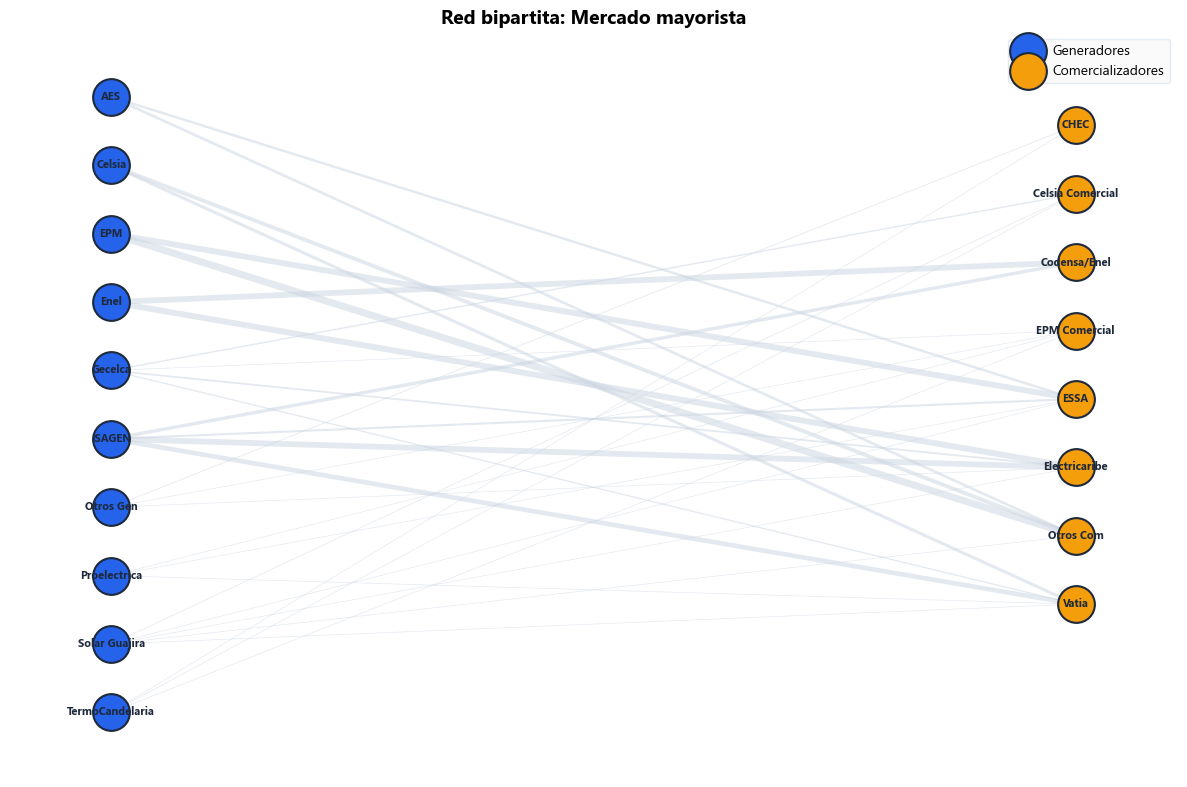

In [12]:
# Crear la red del mercado mayorista
G_mercado = energy_data.crear_red_mercado_mayorista(seed=42)

# Visualizar la red bipartita
fig, ax = plt.subplots(figsize=(12, 8))
diffusion.visualizar_red_bipartita(G_mercado, ax=ax)
plt.tight_layout()
plt.show()

In [13]:
# Análisis detallado
resultados = diffusion.analizar_red_bipartita(G_mercado)

print("Métricas de centralidad en el mercado mayorista:\n")
print(resultados["metricas"].to_string(index=False))

print(f"\n Proyección sobre generadores:")
print(f"   Nodos: {resultados['proyeccion_gen'].number_of_nodes()}")
print(f"   Aristas: {resultados['proyeccion_gen'].number_of_edges()}")
print(f"   (Dos generadores están conectados si comparten un comercializador)")

print(f"\n Proyección sobre comercializadores:")
print(f"   Nodos: {resultados['proyeccion_com'].number_of_nodes()}")
print(f"   Aristas: {resultados['proyeccion_com'].number_of_edges()}")

Métricas de centralidad en el mercado mayorista:

            nodo            tipo  grado  betweenness  volumen_gwh
          ISAGEN       generador      4       0.1498       3485.3
       Otros Com comercializador      4       0.0828       3096.1
   Electricaribe comercializador      5       0.2492       3053.8
             EPM       generador      2       0.0081       2800.7
            Enel       generador      2       0.0229       2547.9
            ESSA comercializador      5       0.1905       2366.6
           Vatia comercializador      5       0.1558       2079.8
    Codensa/Enel comercializador      2       0.0147       2004.6
          Celsia       generador      2       0.0149       1513.4
             AES       generador      2       0.0081       1126.5
         Gecelca       generador      4       0.0964       1077.8
Celsia Comercial comercializador      3       0.0823        507.7
   Solar Guajira       generador      5       0.2366        423.8
   EPM Comercial comercial

## 2.4 Falla en cascada en el SIN 

El **Sistema Interconectado Nacional (SIN)** puede sufrir fallas en cascada:
si una subestación falla, la carga se redistribuye, y otras subestaciones
pueden sobrecargarse y fallar también.

Usamos una versión simplificada del **modelo de Motter-Lai** para visualizar este proceso.

> [WARN] Modelo pedagógico simplificado. El SIN real tiene protecciones y redundancias.

 Falla inicial: Ancón Sur
   Pasos de cascada: 2
   Nodos fallados al final: 2 de 45
   (4% del sistema)


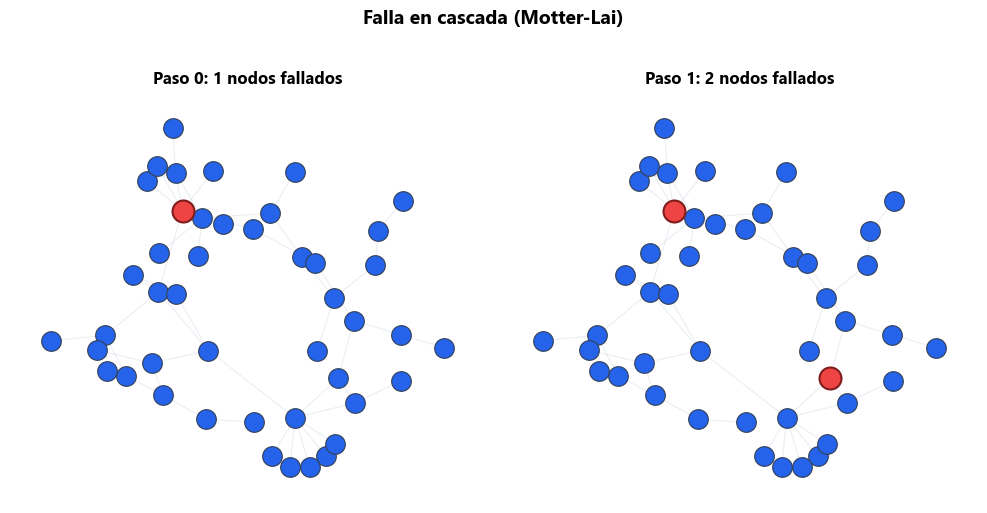

In [14]:
# Crear la red del SIN
G_sin = energy_data.crear_red_sin_simplificada()
layout_sin = nx.spring_layout(G_sin, seed=42, k=2.0/np.sqrt(len(G_sin)))

# Simular falla en cascada desde un hub crítico
nodo_critico = "Ancón Sur"  # Hub de Antioquia

historia_falla, cargas = diffusion.simular_falla_cascada(
    G_sin, nodo_critico, capacidad_factor=1.3
)

# Resumen
print(f" Falla inicial: {nodo_critico}")
print(f"   Pasos de cascada: {len(historia_falla)}")
print(f"   Nodos fallados al final: {len(historia_falla[-1])} de {len(G_sin)}")
print(f"   ({len(historia_falla[-1])/len(G_sin)*100:.0f}% del sistema)")

# Visualizar la cascada
fig = diffusion.plot_falla_cascada(G_sin, historia_falla, layout=layout_sin)
plt.show()

In [15]:
# ¿Qué nodo causa la peor cascada?
nodos_prueba = ["Ancón Sur", "Bacatá", "Cerromatoso", "Yumbo", "Pasto"]
resultados_cascada = []

for nodo in nodos_prueba:
    hist, _ = diffusion.simular_falla_cascada(G_sin, nodo, capacidad_factor=1.3)
    fallados = len(hist[-1])
    resultados_cascada.append({
        "Nodo inicial": nodo,
        "Región": G_sin.nodes[nodo].get("region", "-"),
        "Nodos fallados": fallados,
        "% del sistema": f"{fallados/len(G_sin)*100:.0f}%",
        "Pasos cascada": len(hist),
    })

df_cascadas = pd.DataFrame(resultados_cascada)
print("Vulnerabilidad del SIN según nodo de falla inicial:\n")
print(df_cascadas.to_string(index=False))

print("\n**Nota:** Los hubs regionales (Ancón Sur, Bacatá) causan cascadas más severas")
print("   que los nodos periféricos (Pasto) \u2192 importancia de proteger hubs.")

Vulnerabilidad del SIN según nodo de falla inicial:

Nodo inicial       Región  Nodos fallados % del sistema  Pasos cascada
   Ancón Sur    Antioquia               2            4%              2
      Bacatá Cundinamarca               5           11%              2
 Cerromatoso        Costa               1            2%              1
       Yumbo        Valle               2            4%              2
       Pasto       Nariño               1            2%              1

**Nota:** Los hubs regionales (Ancón Sur, Bacatá) causan cascadas más severas
   que los nodos periféricos (Pasto) → importancia de proteger hubs.


## 2.5 Comunidades en el mercado eléctrico ️

La **detección de comunidades** revela grupos de actores que comercian densamente entre sí.
Esto puede indicar mercados regionales o concentración.

Comunidades detectadas: 2
   Modularidad Q = 0.112

   Comunidad 1: ['Enel', 'Gecelca', 'Otros Gen', 'Solar Guajira', 'TermoCandelaria']
   Comunidad 2: ['AES', 'Celsia', 'EPM', 'ISAGEN', 'Proelectrica']


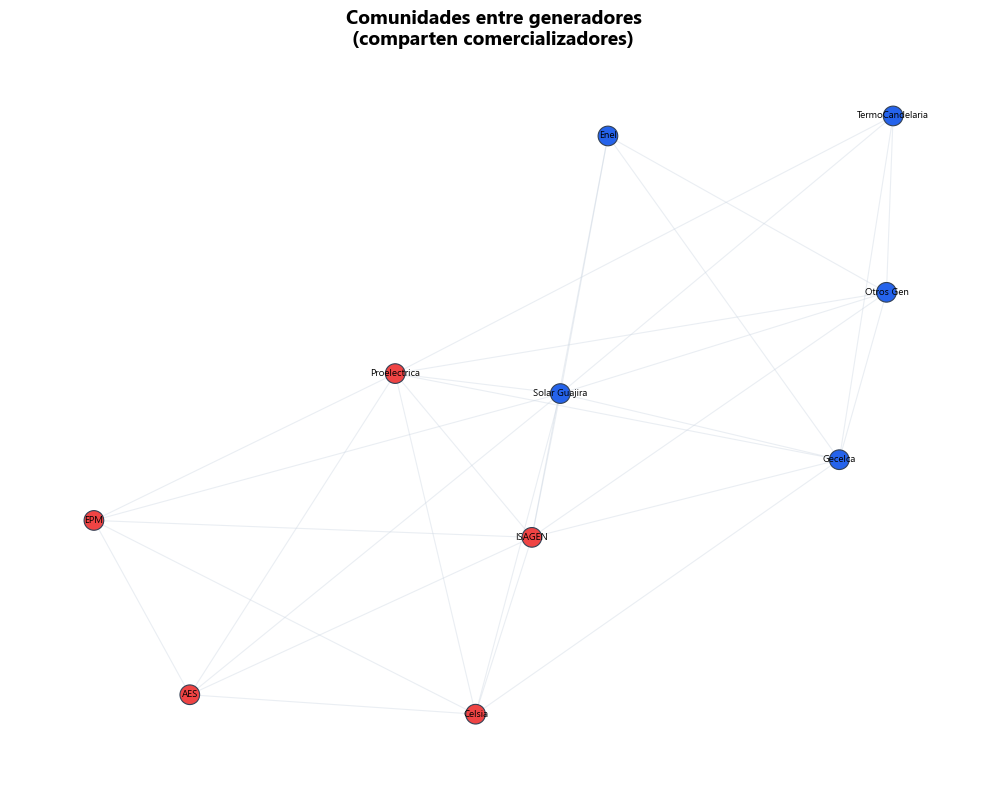

In [16]:
# Detectar comunidades en la proyección de generadores
proy_gen = resultados["proyeccion_gen"]

if proy_gen.number_of_edges() > 0:
    comunidades, Q = diffusion.detectar_comunidades(proy_gen)
    
    print(f"Comunidades detectadas: {len(comunidades)}")
    print(f"   Modularidad Q = {Q:.3f}")
    print()
    for i, com in enumerate(comunidades):
        print(f"   Comunidad {i+1}: {sorted(com)}")
    
    fig, ax = plt.subplots(figsize=(10, 8))
    diffusion.visualizar_comunidades(proy_gen, comunidades, ax=ax)
    ax.set_title("Comunidades entre generadores\n(comparten comercializadores)",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("[WARN] La proyección no tiene aristas suficientes para detectar comunidades.")

Comunidades en el SIN: 6
   Modularidad Q = 0.681

   Comunidad 1 (10 nodos): ['Ancón Sur', 'Barbosa', 'Cartagena', 'Cerromatoso', 'Envigado']...
   Comunidad 2 (9 nodos): ['Bacatá', 'Chivor', 'Guavio', 'Paipa', 'Sogamoso']...
   Comunidad 3 (8 nodos): ['Barranquilla', 'Colectora Guajira', 'Cuestecitas', 'El Paso Solar', 'Santa Marta']...
   Comunidad 4 (7 nodos): ['Alto Anchicayá', 'Jamondino', 'Pasto', 'Popayán', 'Salvajina']...
   Comunidad 5 (6 nodos): ['Betania', 'El Quimbo', 'Ibagué', 'La Rosa', 'La Virginia']...
   Comunidad 6 (5 nodos): ['Arauca', 'Barranca', 'Bucaramanga', 'Cúcuta', 'Puerto Berrío']...


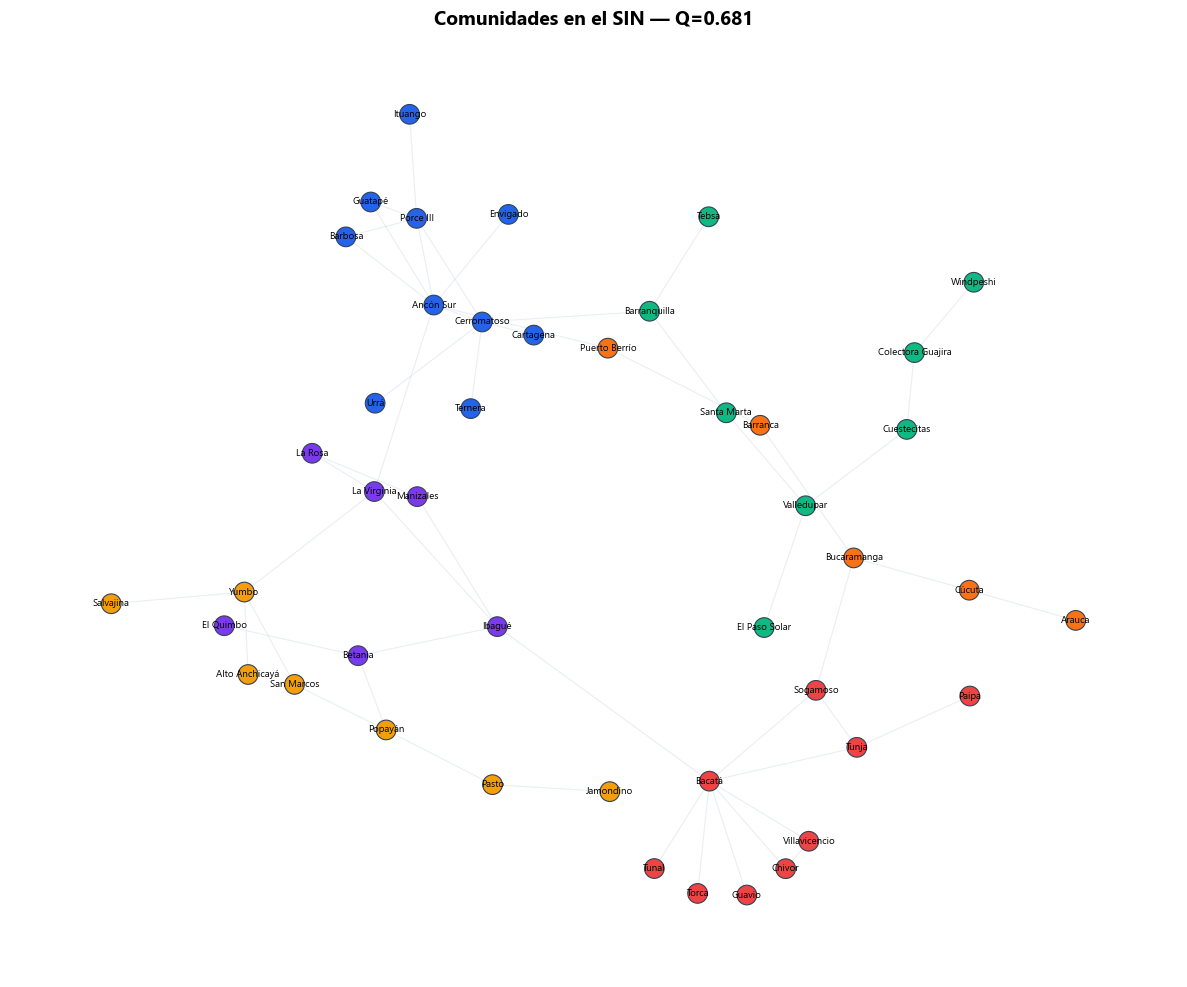


**Nota:** Las comunidades reflejan la estructura geográfica del SIN:
   corredores regionales con pocas interconexiones.


In [17]:
# Detectar comunidades en el SIN
comunidades_sin, Q_sin = diffusion.detectar_comunidades(G_sin)

print(f"Comunidades en el SIN: {len(comunidades_sin)}")
print(f"   Modularidad Q = {Q_sin:.3f}")
print()
for i, com in enumerate(comunidades_sin):
    print(f"   Comunidad {i+1} ({len(com)} nodos): {sorted(list(com))[:5]}...")

fig, ax = plt.subplots(figsize=(12, 10))
diffusion.visualizar_comunidades(G_sin, comunidades_sin, layout=layout_sin, ax=ax)
ax.set_title(f"Comunidades en el SIN \u2014 Q={Q_sin:.3f}", fontweight="bold")
plt.tight_layout()
plt.show()

print("\n**Nota:** Las comunidades reflejan la estructura geográfica del SIN:")
print("   corredores regionales con pocas interconexiones.")

---
# Nivel 3 **Nivel 3 —** Profesional: Herramientas avanzadas de difusión y resiliencia

> Para quienes quieran ir más allá en sus proyectos profesionales.

## 3.1 Modelos basados en agentes (ABM) con Mesa 

**Agent-Based Modeling** permite simular difusión con agentes heterogéneos:
- Cada hogar es un agente con ingresos, preferencias, vecinos
- Decisiones basadas en reglas locales (umbrales, imitación, racionalidad limitada)
- Patrones macro emergen de interacciones micro

**Herramienta recomendada:** [Mesa](https://mesa.readthedocs.io/) (Python)

```python
# Ejemplo conceptual (NO ejecutar sin instalar mesa)
from mesa import Agent, Model
from mesa.space import NetworkGrid

class HogarSolar(Agent):
    def __init__(self, unique_id, model, umbral):
        super().__init__(unique_id, model)
        self.adoptado = False
        self.umbral = umbral
    
    def step(self):
        vecinos = self.model.grid.get_neighbors(self.pos)
        adoptantes = sum(1 for v in vecinos if v.adoptado)
        if adoptantes / max(len(vecinos), 1) >= self.umbral:
            self.adoptado = True
```

**¿Cuándo usar ABM vs modelos de red?**
| Característica | Red + umbrales | ABM (Mesa) |
|---------------|----------------|------------|
| Heterogeneidad | Limitada | Alta |
| Reglas de decisión | Simple (umbral) | Complejas |
| Escalabilidad | Alta | Media |
| Facilidad | Alta | Media |

## 3.2 Modelos de difusión para diseño de política energética 

**Aplicaciones en política pública:**

1. **Diseño de subsidios óptimos**: Usar la ventana de cascada para encontrar el umbral mínimo de subsidio que genera adopción masiva.

2. **Selección de "semillas"**: ¿Dónde instalar los primeros paneles solares de demostración? Los nodos con alta centralidad son mejores semillas.

3. **Predicción con Bass**: Calibrar p y q con datos históricos para proyectar adopción futura y planificar infraestructura.

**Referencia clave:**
- Rogers, E.M. (2003). *Diffusion of Innovations*. Free Press.
- Bass, F.M. (1969). "A New Product Growth for Model Consumer Durables." *Management Science*, 15(5).
- Watts, D.J. (2002). "A simple model of global cascades on random networks." *PNAS*.

## 3.3 Resiliencia de redes: más allá del tipping point ️

**¿Cómo hacer una red más resiliente?**

1. **Redundancia**: Agregar caminos alternativos (el SIN tiene pocos entre regiones)
2. **Descentralización**: Generación distribuida reduce dependencia de hubs
3. **Detección temprana**: Monitorear métricas de centralidad en tiempo real

**Herramientas y referencias:**
- **Motter & Lai (2002)**: "Cascade-based attacks on complex networks." *Physical Review E*.
- **Colorado State University**: [Network Resilience Lab](https://www.engr.colostate.edu/)
- **Resiltech**: Herramientas de análisis de resiliencia para infraestructura crítica.

**En el contexto colombiano:**
- La interconexión Guajira es un corredor crítico para los proyectos eólicos
- El corredor Antioquia-Costa depende de pocos enlaces
- La generación distribuida (Ley 1715/2014, Ley 2099/2021) diversifica el riesgo

---
#  Cierre: Lo que aprendimos esta semana

| Concepto | Herramienta | Aplicación energética |
|----------|-------------|----------------------|
| Contagio simple (SI) | `simular_contagio_simple()` | Propagación de información |
| Contagio complejo | Modelo de umbrales | Adopción solar |
| Curva S | Modelo de Bass | Proyección de FNCER |
| Red bipartita | Proyecciones | Poder de mercado |
| Falla en cascada | Motter-Lai | Vulnerabilidad del SIN |
| Comunidades | Modularidad | Estructura del mercado |

###  Próxima semana: Semana 4 — Dinámica de Sistemas

En la Semana 4 formalizaremos las **ecuaciones diferenciales** que ya vimos con Bass:
- Diagramas de stocks y flujos
- Retroalimentación con retardos
- Modelado con `scipy.integrate` y Vensim/Stella

> **Puente conceptual:** El modelo de Bass es una ODE. La dinámica de sistemas toma esta idea y la extiende a sistemas con MÚLTIPLES variables retroalimentadas.

In [18]:
print("="*60)
print("   Semana 3 completada: Dinámica sobre Redes")
print("="*60)
print()
print("  Módulos utilizados:")
print("  \u2022 diffusion \u2014 contagio, umbrales, Bass, bipartitas")
print("  \u2022 energy_data \u2014 datos del sector eléctrico colombiano")
print("  \u2022 viz \u2014 estilos y visualización")
print()
print("  \u2192 Siguiente: Semana 4 \u2014 Dinámica de Sistemas")

   Semana 3 completada: Dinámica sobre Redes

  Módulos utilizados:
  • diffusion — contagio, umbrales, Bass, bipartitas
  • energy_data — datos del sector eléctrico colombiano
  • viz — estilos y visualización

  → Siguiente: Semana 4 — Dinámica de Sistemas
